# Schur Complement Cost — Step-by-Step Walkthrough

This notebook walks through the math of both Schur complement methods
on a tiny mesh where you can see exactly which matrix entries correspond
to which vertices.

**Setup:** A 3×3 grid (9 vertices, 8 triangles). We'll:
1. Build the stiffness matrix K and label which blocks belong to which vertex
2. Pick an edge to collapse
3. Walk through the **simple trace metric** (Schur flow)
4. Walk through the **full Schur mismatch** cost
5. Show what changes after collapse

In [1]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from kms.mesh import TriMesh, make_grid
from kms.adjacency import MeshAdjacency
from kms.stiffness import shell_stiffness

np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 1. The Mesh

A 3×3 grid: 9 vertices, each with 3 DOFs (x,y,z), giving a 27×27 stiffness matrix.

Vertex numbering:
```
6 — 7 — 8
|\  |\  |
| \ | \ |
|  \|  \|
3 — 4 — 5
|\  |\  |
| \ | \ |
|  \|  \|
0 — 1 — 2
```

We'll focus on collapsing edge **(3, 4)** — an interior edge where vertex 4 is the center.

In [2]:
mesh = make_grid(3, 3)
adj = MeshAdjacency(mesh)

print(f"Vertices: {mesh.n_verts}")
print(f"Faces: {mesh.n_faces}")
print(f"Edges: {len(adj.get_edges())}")
print()
print("Vertex positions:")
for i, v in enumerate(mesh.vertices):
    print(f"  v{i}: ({v[0]:.1f}, {v[1]:.1f}, {v[2]:.1f})")
print()
print("Faces (triangles):")
for i, f in enumerate(mesh.faces):
    print(f"  f{i}: [{f[0]}, {f[1]}, {f[2]}]")

Vertices: 9
Faces: 8
Edges: 16

Vertex positions:
  v0: (0.0, 0.0, 0.0)
  v1: (0.5, 0.0, 0.0)
  v2: (1.0, 0.0, 0.0)
  v3: (0.0, 0.5, 0.0)
  v4: (0.5, 0.5, 0.0)
  v5: (1.0, 0.5, 0.0)
  v6: (0.0, 1.0, 0.0)
  v7: (0.5, 1.0, 0.0)
  v8: (1.0, 1.0, 0.0)

Faces (triangles):
  f0: [0, 1, 4]
  f1: [0, 4, 3]
  f2: [1, 2, 5]
  f3: [1, 5, 4]
  f4: [3, 4, 7]
  f5: [3, 7, 6]
  f6: [4, 5, 8]
  f7: [4, 8, 7]


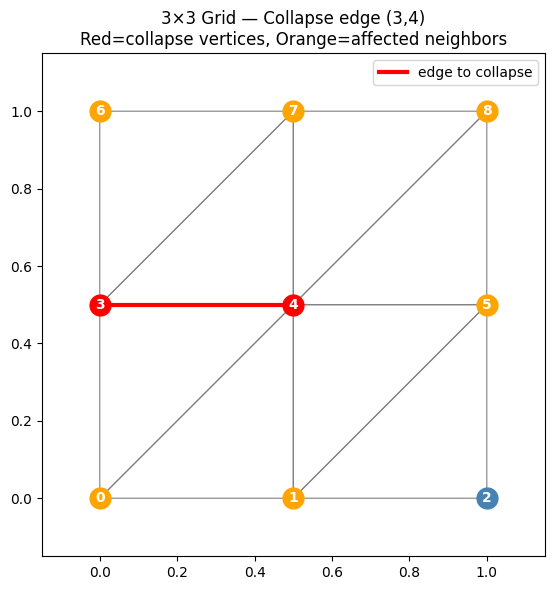

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Draw triangles
for f in mesh.faces:
    tri = plt.Polygon(mesh.vertices[f][:, :2], fill=False, edgecolor='gray', linewidth=0.8)
    ax.add_patch(tri)

# Highlight edge (3, 4)
ax.plot([mesh.vertices[3, 0], mesh.vertices[4, 0]],
        [mesh.vertices[3, 1], mesh.vertices[4, 1]], 'r-', linewidth=3, label='edge to collapse')

# Draw vertices
for i, v in enumerate(mesh.vertices):
    color = 'red' if i in (3, 4) else ('orange' if i in adj.vert_neighbors[3] | adj.vert_neighbors[4] else 'steelblue')
    ax.plot(v[0], v[1], 'o', markersize=15, color=color, zorder=5)
    ax.text(v[0], v[1], str(i), ha='center', va='center', fontsize=10, fontweight='bold', color='white', zorder=6)

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.15)
ax.set_aspect('equal')
ax.set_title('3×3 Grid — Collapse edge (3,4)\nRed=collapse vertices, Orange=affected neighbors')
ax.legend()
plt.tight_layout()
plt.show()

## 2. The Stiffness Matrix K

K is 27×27 (9 vertices × 3 DOFs each). Each 3×3 block `K[3i:3i+3, 3j:3j+3]` encodes
the mechanical coupling between vertices i and j.

- **Diagonal block** K_vv: self-stiffness of vertex v (how much it resists displacement)
- **Off-diagonal block** K_ij: coupling between vertices i and j (nonzero only for neighbors)

In [7]:
K_total, K_m, K_b = shell_stiffness(mesh)
K = K_total.toarray()

print(f"K shape: {K.shape}")
print(f"K nonzeros: {np.count_nonzero(np.abs(K) > 1e-15)}")
print(f"K symmetric: {np.allclose(K, K.T)}")

print(K)

K shape: (27, 27)
K nonzeros: 167
K symmetric: True
[[ 0.0011  0.      0.     -0.0005 -0.0002  0.      0.      0.      0.     -0.0005  0.0002  0.      0.     -0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.0004  0.     -0.0002 -0.0002  0.      0.      0.      0.      0.0002 -0.0002  0.     -0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.     -0.      0.      0.      0.      0.      0.     -0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.0005 -0.0002  0.      0.0018  0.0004  0.     -0.0005 -0.0002  0.      0.      0.      0.     -0.0007  0.
   0.      0.     -0.      0.      0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [-0.0002 -0.0002  0.      0.0004  0.0011  0.     -0.0002 -0.0002  0.      0.   

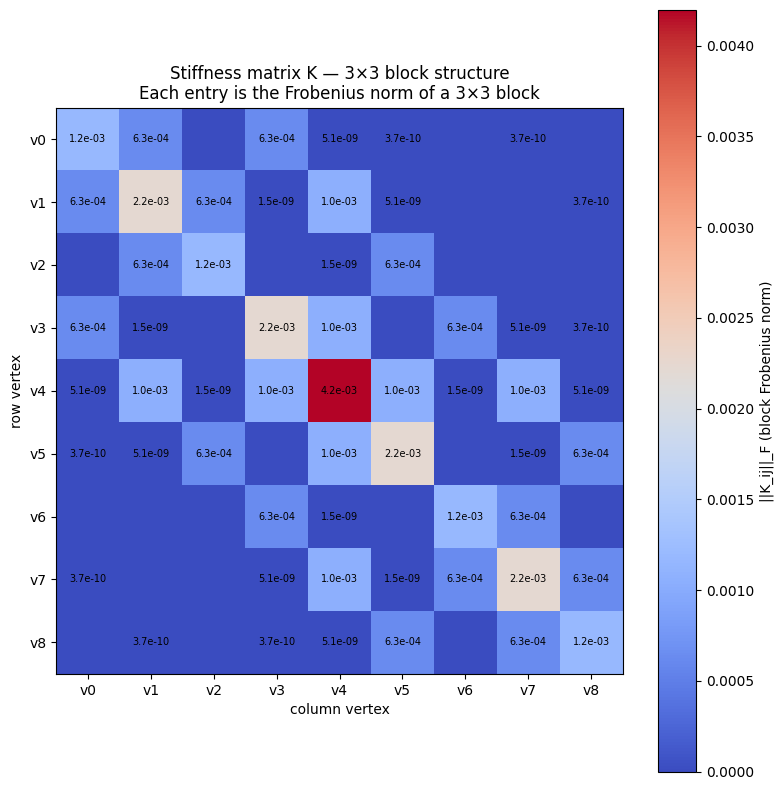


Nonzero blocks correspond to mesh edges (neighbors):
  Neighbors of v4 (center): [0, 1, 3, 5, 7, 8]
  Neighbors of v3: [0, 4, 6, 7]


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Show block structure
block_norms = np.zeros((9, 9))
for i in range(9):
    for j in range(9):
        block = K[3*i:3*i+3, 3*j:3*j+3]
        block_norms[i, j] = np.linalg.norm(block, 'fro')

im = ax.imshow(block_norms, cmap='coolwarm', aspect='equal')
plt.colorbar(im, ax=ax, label='||K_ij||_F (block Frobenius norm)')

# Label
for i in range(9):
    for j in range(9):
        if block_norms[i, j] > 1e-10:
            ax.text(j, i, f'{block_norms[i,j]:.1e}', ha='center', va='center', fontsize=7)

ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.set_xticklabels([f'v{i}' for i in range(9)])
ax.set_yticklabels([f'v{i}' for i in range(9)])
ax.set_title('Stiffness matrix K — 3×3 block structure\nEach entry is the Frobenius norm of a 3×3 block')
ax.set_xlabel('column vertex')
ax.set_ylabel('row vertex')
plt.tight_layout()
plt.show()

print("\nNonzero blocks correspond to mesh edges (neighbors):")
print(f"  Neighbors of v4 (center): {sorted(adj.vert_neighbors[4])}")
print(f"  Neighbors of v3: {sorted(adj.vert_neighbors[3])}")

## 3. Simple Metric: Schur Flow

For vertex v, the Schur flow measures "how much stiffness flows through v to its neighbors":

$$\text{flow}(v) = \text{trace}\left(K_{vv}^{-1} \cdot S\right)$$

where $S = \sum_{j \in N(v)} K_{vj} \cdot K_{jv}$

**Intuition:** $K_{vj}$ is the 3×3 coupling from v to neighbor j. The product $K_{vj} K_{jv}$
measures how much force on j "bounces back" through v. Summing over all neighbors gives
the total stiffness that routes through v. Normalizing by $K_{vv}^{-1}$ makes it relative
to v's own stiffness.

Let's compute this step-by-step for **vertex 4** (the center vertex we want to eliminate).

In [8]:
v = 4  # vertex to eliminate
dofs_v = [3*v, 3*v+1, 3*v+2]

# Step 1: Extract K_vv (3×3 self-stiffness)
K_vv = K[np.ix_(dofs_v, dofs_v)]
print(np.linalg.norm(K_vv, 'fro'))
print(f"K_vv (self-stiffness of vertex {v}):")
print(K_vv)
print(f"\nDiagonal sum: {np.trace(K_vv):.6e}")
print(f"This tells us how much vertex {v} resists displacement in each direction.")

0.004196018262017059
K_vv (self-stiffness of vertex 4):
[[ 0.003 -0.     0.   ]
 [-0.     0.003  0.   ]
 [ 0.     0.     0.   ]]

Diagonal sum: 5.934082e-03
This tells us how much vertex 4 resists displacement in each direction.


In [9]:
# Step 2: Extract coupling blocks K_vj for each neighbor j
neighbors_v = sorted(adj.vert_neighbors[v])
print(f"Neighbors of vertex {v}: {neighbors_v}\n")

coupling_blocks = {}
for j in neighbors_v:
    dofs_j = [3*j, 3*j+1, 3*j+2]
    K_vj = K[np.ix_(dofs_v, dofs_j)]
    coupling_blocks[j] = K_vj
    print(f"K_v{v},v{j} (coupling v{v} → v{j}):")
    print(f"  {K_vj[0]}")
    print(f"  {K_vj[1]}")
    print(f"  {K_vj[2]}")
    print(f"  ||K_v{v},v{j}||_F = {np.linalg.norm(K_vj, 'fro'):.6e}\n")

Neighbors of vertex 4: [0, 1, 3, 5, 7, 8]

K_v4,v0 (coupling v4 → v0):
  [ 0. -0.  0.]
  [-0.  0.  0.]
  [0. 0. 0.]
  ||K_v4,v0||_F = 5.128205e-09

K_v4,v1 (coupling v4 → v1):
  [-0.0007  0.      0.    ]
  [ 0.     -0.0007  0.    ]
  [ 0.  0. -0.]
  ||K_v4,v1||_F = 1.049005e-03

K_v4,v3 (coupling v4 → v3):
  [-0.0007  0.      0.    ]
  [ 0.     -0.0007  0.    ]
  [ 0.  0. -0.]
  ||K_v4,v3||_F = 1.049005e-03

K_v4,v5 (coupling v4 → v5):
  [-0.0007  0.      0.    ]
  [ 0.     -0.0007  0.    ]
  [ 0.  0. -0.]
  ||K_v4,v5||_F = 1.049005e-03

K_v4,v7 (coupling v4 → v7):
  [-0.0007  0.      0.    ]
  [ 0.     -0.0007  0.    ]
  [ 0.  0. -0.]
  ||K_v4,v7||_F = 1.049005e-03

K_v4,v8 (coupling v4 → v8):
  [ 0. -0.  0.]
  [-0.  0.  0.]
  [0. 0. 0.]
  ||K_v4,v8||_F = 5.128205e-09



In [10]:
# Step 3: Compute S = sum of K_vj @ K_jv over all neighbors
S = np.zeros((3, 3))
print("Computing S = Σ_j K_vj @ K_jv:\n")

for j in neighbors_v:
    dofs_j = [3*j, 3*j+1, 3*j+2]
    K_vj = K[np.ix_(dofs_v, dofs_j)]
    K_jv = K[np.ix_(dofs_j, dofs_v)]
    product = K_vj @ K_jv
    S += product
    print(f"  K_v{v},v{j} @ K_v{j},v{v}:  trace = {np.trace(product):.6e}")

print(f"\nS (total coupling product):")
print(S)
print(f"\ntrace(S) = {np.trace(S):.6e}")
print("\nS encodes the total stiffness that 'flows through' vertex 4 to all its neighbors.")

Computing S = Σ_j K_vj @ K_jv:

  K_v4,v0 @ K_v0,v4:  trace = 2.629849e-17
  K_v4,v1 @ K_v1,v4:  trace = 1.100411e-06
  K_v4,v3 @ K_v3,v4:  trace = 1.100411e-06
  K_v4,v5 @ K_v5,v4:  trace = 1.100411e-06
  K_v4,v7 @ K_v7,v4:  trace = 1.100411e-06
  K_v4,v8 @ K_v8,v4:  trace = 2.629849e-17

S (total coupling product):
[[ 0. -0.  0.]
 [-0.  0.  0.]
 [ 0.  0.  0.]]

trace(S) = 4.401642e-06

S encodes the total stiffness that 'flows through' vertex 4 to all its neighbors.


In [11]:
# Step 4: Compute flow = trace(K_vv^{-1} @ S)
K_vv_inv = np.linalg.inv(K_vv)
print("K_vv^{-1}:")
print(K_vv_inv)

flow_v = np.trace(K_vv_inv @ S)
print(f"\nflow(v{v}) = trace(K_vv^{{-1}} @ S) = {flow_v:.6e}")
print(f"\nInterpretation: the stiffness flowing through v{v}, normalized by its own stiffness.")
print(f"Higher = more important as a conduit. This vertex would be expensive to remove.")

K_vv^{-1}:
[[     337.037         0.            0.    ]
 [       0.          337.037         0.    ]
 [       0.            0.     62045454.5455]]

flow(v4) = trace(K_vv^{-1} @ S) = 1.483528e-03

Interpretation: the stiffness flowing through v4, normalized by its own stiffness.
Higher = more important as a conduit. This vertex would be expensive to remove.


In [12]:
# Compare flow across all vertices
from kms.schur import per_vertex_schur_flow

all_flow = per_vertex_schur_flow(K_total, mesh)

print("Schur flow for all vertices:")
print("  Vertex  Position        Flow        Role")
print("  ------  --------        ----        ----")
for i in range(9):
    pos = mesh.vertices[i]
    role = "corner" if i in (0,2,6,8) else ("edge" if i in (1,3,5,7) else "center")
    print(f"  v{i}      ({pos[0]:.1f},{pos[1]:.1f})      {all_flow[i]:.6e}   {role}")

print(f"\nCenter (v4) flow: {all_flow[4]:.6e}")
print(f"Corner mean flow: {np.mean(all_flow[[0,2,6,8]]):.6e}")
print(f"Edge mean flow:   {np.mean(all_flow[[1,3,5,7]]):.6e}")
print("\nCenter has highest flow — most connected, hardest to remove.")
print("Corners have lowest flow — fewest neighbors, cheapest to remove.")

Schur flow for all vertices:
  Vertex  Position        Flow        Role
  ------  --------        ----        ----
  v0      (0.0,0.0)      9.835238e-04   corner
  v1      (0.5,0.0)      1.259100e-03   edge
  v2      (1.0,0.0)      9.835282e-04   corner
  v3      (0.0,0.5)      1.259100e-03   edge
  v4      (0.5,0.5)      1.483528e-03   center
  v5      (1.0,0.5)      1.259100e-03   edge
  v6      (0.0,1.0)      9.835282e-04   corner
  v7      (0.5,1.0)      1.259100e-03   edge
  v8      (1.0,1.0)      9.835238e-04   corner

Center (v4) flow: 1.483528e-03
Corner mean flow: 9.835260e-04
Edge mean flow:   1.259100e-03

Center has highest flow — most connected, hardest to remove.
Corners have lowest flow — fewest neighbors, cheapest to remove.


## 4. Full Metric: Schur Complement Mismatch

Now let's collapse edge **(3, 4)** and compare:
- **K\* (Schur complement):** what the stiffness *should* be if we could eliminate v4 perfectly
- **K' (actual):** what the stiffness *is* after the topology change

The cost = ||K' - K\*||²_F on the affected patch.

### Step 1: The Schur complement (ideal elimination)

Partition K into blocks around vertex 4:
$$K = \begin{bmatrix} K_{BB} & K_{Bv} \\ K_{vB} & K_{vv} \end{bmatrix}$$

The Schur complement eliminates v4's DOFs:
$$K^* = K_{BB} - K_{Bv} \cdot K_{vv}^{-1} \cdot K_{vB}$$

The correction term $K_{Bv} \cdot K_{vv}^{-1} \cdot K_{vB}$ redistributes v4's mechanical
contribution to its neighbors. It's rank-3 (3 DOFs eliminated) and only affects the
rows/columns of v4's neighbors.

In [13]:
# For clarity, work on the local patch (vertices in 1-ring of 3 and 4)
u, v = 3, 4
patch_verts = sorted({u, v} | adj.vert_neighbors[u] | adj.vert_neighbors[v])
print(f"Collapsing edge ({u}, {v})")
print(f"Affected patch vertices: {patch_verts}")
print(f"  v{u} neighbors: {sorted(adj.vert_neighbors[u])}")
print(f"  v{v} neighbors: {sorted(adj.vert_neighbors[v])}")
print()

# Extract patch stiffness from global K
patch_dofs = []
for vi in patch_verts:
    patch_dofs.extend([3*vi, 3*vi+1, 3*vi+2])
K_patch = K[np.ix_(patch_dofs, patch_dofs)]
print(f"Patch stiffness K_patch: {K_patch.shape[0]}×{K_patch.shape[1]}")
print(f"  ({len(patch_verts)} vertices × 3 DOFs)")

Collapsing edge (3, 4)
Affected patch vertices: [0, 1, 3, 4, 5, 6, 7, 8]
  v3 neighbors: [0, 4, 6, 7]
  v4 neighbors: [0, 1, 3, 5, 7, 8]

Patch stiffness K_patch: 24×24
  (8 vertices × 3 DOFs)


In [14]:
# Partition into v4's DOFs (A) and everyone else (B)
v_local_idx = patch_verts.index(v)  # local index of v4 in patch
dofs_A = [3*v_local_idx, 3*v_local_idx+1, 3*v_local_idx+2]
dofs_B = [i for i in range(len(patch_dofs)) if i not in dofs_A]

print(f"Vertex {v} is at local index {v_local_idx} in the patch")
print(f"DOFs A (to eliminate): {dofs_A}  (vertex {v}'s x,y,z)")
print(f"DOFs B (to keep): {dofs_B}  ({len(dofs_B)//3} vertices)")
print()

# Extract blocks
K_AA = K_patch[np.ix_(dofs_A, dofs_A)]  # 3×3
K_AB = K_patch[np.ix_(dofs_A, dofs_B)]  # 3×(n-3)
K_BA = K_patch[np.ix_(dofs_B, dofs_A)]  # (n-3)×3
K_BB = K_patch[np.ix_(dofs_B, dofs_B)]  # (n-3)×(n-3)

print(f"K_AA (v{v} self-stiffness): {K_AA.shape}")
print(K_AA)
print(f"\nK_AB (v{v} coupling to others): {K_AB.shape}")
print(f"  Nonzero columns (neighbors of v{v} in patch): ", end="")
nonzero_cols = np.where(np.any(np.abs(K_AB) > 1e-15, axis=0))[0]
# Map back to vertex IDs
remaining_verts = [vi for vi in patch_verts if vi != v]
print([remaining_verts[c//3] for c in nonzero_cols[::3]])

Vertex 4 is at local index 3 in the patch
DOFs A (to eliminate): [9, 10, 11]  (vertex 4's x,y,z)
DOFs B (to keep): [0, 1, 2, 3, 4, 5, 6, 7, 8, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]  (7 vertices)

K_AA (v4 self-stiffness): (3, 3)
[[ 0.003 -0.     0.   ]
 [-0.     0.003  0.   ]
 [ 0.     0.     0.   ]]

K_AB (v4 coupling to others): (3, 21)
  Nonzero columns (neighbors of v4 in patch): [0, 1, 3, 5, 7]


In [16]:
# Compute the Schur complement
K_AA_inv = np.linalg.inv(K_AA)
correction = K_BA @ K_AA_inv @ K_AB
print("trace: ", np.linalg.trace(correction))
K_schur = K_BB - correction

print("Schur complement: K* = K_BB - K_BA @ K_AA^{-1} @ K_AB")
print(f"\nCorrection term shape: {correction.shape}")
print(f"Correction rank: {np.linalg.matrix_rank(correction, tol=1e-12)} (should be ≤ 3)")
print(f"Correction Frobenius norm: {np.linalg.norm(correction, 'fro'):.6e}")
print()
print("The correction redistributes v4's stiffness to its neighbors.")
print("Let's see which vertex pairs get the biggest correction:")
print()

# Show correction in block form
n_remaining = len(remaining_verts)
print(f"  {'':8s}", end="")
for j in remaining_verts:
    print(f"{'v'+str(j):>10s}", end="")
print()
for i_idx, i in enumerate(remaining_verts):
    print(f"  v{i:1d}      ", end="")
    for j_idx, j in enumerate(remaining_verts):
        block = correction[3*i_idx:3*i_idx+3, 3*j_idx:3*j_idx+3]
        norm = np.linalg.norm(block, 'fro')
        print(f"{norm:10.2e}", end="")
    print()

trace:  0.0014835284049284055
Schur complement: K* = K_BB - K_BA @ K_AA^{-1} @ K_AB

Correction term shape: (21, 21)
Correction rank: 3 (should be ≤ 3)
Correction Frobenius norm: 1.049005e-03

The correction redistributes v4's stiffness to its neighbors.
Let's see which vertex pairs get the biggest correction:

                  v0        v1        v3        v5        v6        v7        v8
  v0        1.63e-09  1.86e-09  1.86e-09  1.86e-09  4.66e-10  1.86e-09  1.63e-09
  v1        1.86e-09  2.62e-04  2.62e-04  2.62e-04  5.33e-10  2.62e-04  1.86e-09
  v3        1.86e-09  2.62e-04  2.62e-04  2.62e-04  5.33e-10  2.62e-04  1.86e-09
  v5        1.86e-09  2.62e-04  2.62e-04  2.62e-04  5.33e-10  2.62e-04  1.86e-09
  v6        4.66e-10  5.33e-10  5.33e-10  5.33e-10  1.33e-10  5.33e-10  4.66e-10
  v7        1.86e-09  2.62e-04  2.62e-04  2.62e-04  5.33e-10  2.62e-04  1.86e-09
  v8        1.63e-09  1.86e-09  1.86e-09  1.86e-09  4.66e-10  1.86e-09  1.63e-09


### Step 2: Actual post-collapse stiffness

When we collapse edge (3,4) → vertex 3 at the midpoint:
- Vertex 4 is removed
- Faces shared by vertices 3 and 4 are deleted
- Vertex 4's remaining faces get remapped: 4 → 3
- Vertex 3 moves to the midpoint

We reassemble element stiffnesses on this new topology → K'

In [17]:
# What faces are shared by (3, 4)?
edge_key = (min(u, v), max(u, v))
shared = adj.edge_faces.get(edge_key, set())
print(f"Shared faces of edge ({u},{v}): {shared}")
for fi in shared:
    print(f"  face {fi}: vertices {list(adj.faces[fi])}")

print(f"\nFaces of v{v} that survive (get v{v}→v{u} remap):")
for fi in adj.vert_faces[v]:
    if fi not in shared:
        face = list(adj.faces[fi])
        remapped = [u if x == v else x for x in face]
        print(f"  face {fi}: {face} → {remapped}")

Shared faces of edge (3,4): {1, 4}
  face 1: vertices [np.int64(0), np.int64(4), np.int64(3)]
  face 4: vertices [np.int64(3), np.int64(4), np.int64(7)]

Faces of v4 that survive (get v4→v3 remap):
  face 0: [np.int64(0), np.int64(1), np.int64(4)] → [np.int64(0), np.int64(1), 3]
  face 3: [np.int64(1), np.int64(5), np.int64(4)] → [np.int64(1), np.int64(5), 3]
  face 6: [np.int64(4), np.int64(5), np.int64(8)] → [3, np.int64(5), np.int64(8)]
  face 7: [np.int64(4), np.int64(8), np.int64(7)] → [3, np.int64(8), np.int64(7)]


In [ ]:
# Compute actual post-collapse stiffness using edge_cost_full
from kms.schur import edge_cost_full

alpha = 0.5  # midpoint
cost = edge_cost_full(mesh, u, v, alpha)
print(f"Full Schur mismatch cost for edge ({u},{v}) at alpha={alpha}:")
print(f"  ||K' - K*||²_F = {cost:.6e}")
print()
print(f"Compare to Schur correction magnitude: ||correction||²_F = {np.linalg.norm(correction, 'fro')**2:.6e}")
print()
print("The mismatch cost tells us: how much stiffness is LOST by the topology change")
print("that the Schur complement would have preserved exactly.")

Full Schur mismatch cost for edge (3,4) at alpha=0.5:
  ||K' - K*||²_F = 2.898729e-06

Compare to Schur correction magnitude: ||correction||²_F = 1.100411e-06

The mismatch cost tells us: how much stiffness is LOST by the topology change
that the Schur complement would have preserved exactly.


In [ ]:
# Let's also try different alpha values to see how position affects cost
alphas = np.linspace(0, 1, 11)
costs_by_alpha = [edge_cost_full(mesh, u, v, a) for a in alphas]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(alphas, costs_by_alpha, 'o-', color='steelblue', linewidth=2)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='midpoint')
best_alpha = alphas[np.argmin(costs_by_alpha)]
ax.axvline(best_alpha, color='green', linestyle='--', alpha=0.5, label=f'best α={best_alpha:.1f}')
ax.set_xlabel('α (0 = keep at v3, 1 = move to v4)')
ax.set_ylabel('||K\' - K*||²_F')
ax.set_title(f'Full Schur mismatch cost vs. collapse position — edge ({u},{v})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best alpha: {best_alpha:.2f} (cost = {min(costs_by_alpha):.6e})")
print(f"Midpoint cost: {costs_by_alpha[5]:.6e}")

## 5. Comparing the Two Methods

| | Simple (Schur flow) | Full (Schur mismatch) |
|---|---|---|
| **Computes** | How much stiffness flows through v | How much stiffness is lost by the topology change |
| **Formula** | trace(K_vv⁻¹ · Σ K_vj K_jv) | \|\|K' - K*\|\|²_F |
| **Cost** | O(1) per vertex (3×3 ops × neighbors) | O(patch²) per edge (element reassembly) |
| **Depends on α** | No | Yes |
| **What it misses** | Topology change effect | Nothing (but expensive) |

In [ ]:
# Compare both metrics for all edges on this mesh
from kms.schur import per_edge_costs_full, edge_cost_simple

edges_s, costs_s = edge_cost_simple(K_total, mesh)
edges_f, costs_f = per_edge_costs_full(mesh, alpha=0.5)

print(f"{'Edge':<10s} {'Simple':>12s} {'Full':>12s} {'Collapsible':>12s}")
print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*12}")
for i, ((eu, ev), cs) in enumerate(zip(edges_s, costs_s)):
    cf = costs_f[i]
    collapsible = adj.is_collapsible(eu, ev)
    marker = '✓' if collapsible else '✗'
    if np.isfinite(cf):
        print(f"({eu},{ev})     {cs:12.4e} {cf:12.4e} {marker:>12s}")
    else:
        print(f"({eu},{ev})     {cs:12.4e} {'inf':>12s} {marker:>12s}")

In [ ]:
# Scatter plot: simple vs full cost
mask = np.isfinite(costs_f)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(costs_s[mask], costs_f[mask], s=60, alpha=0.7, color='steelblue', edgecolors='navy')

for i, (eu, ev) in enumerate(edges_s):
    if mask[i]:
        ax.annotate(f'({eu},{ev})', (costs_s[i], costs_f[i]),
                    fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Simple cost (Schur flow of eliminated vertex)')
ax.set_ylabel('Full cost (||K\' - K*||²_F)')
ax.set_title('Simple vs. Full Schur cost — all edges')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insight: if the points form a clear trend, the simple metric")
print("reliably predicts collapse priority. Scatter means the simple metric")
print("misjudges some edges.")

## Summary

**Simple metric (Schur flow):**
- Cheap to compute (one 3×3 inverse + neighbor products per vertex)
- Answers: "how much stiffness would NEED to be redistributed if we removed this vertex?"
- Does NOT account for the topology change — assumes the Schur complement can be realized perfectly

**Full metric (Schur mismatch):**
- Expensive (reassemble elements on modified topology per edge)
- Answers: "how much stiffness is ACTUALLY lost by the collapse (topology change included)?"
- The gap between the ideal (Schur) and actual (collapsed) stiffness

**The Schur complement itself** is not an approximation — it's the exact mechanical
condensation for linear elasticity. The error comes entirely from the topology change
(removing triangles, changing which elements exist). The full cost measures exactly this error.